In [37]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from pydantic import SecretStr

import os
from dotenv import load_dotenv
load_dotenv()

True

In [38]:
# === Utility Functions ===
def get_secret(key_name: str) -> SecretStr:
    value = os.getenv(key_name)
    if not value:
        raise ValueError(
            f"❌ {key_name} not found. Please set it in your .env file.")
    return SecretStr(value)

In [39]:
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.5,
    api_key=get_secret("GROQ_API_KEY")
)

In [40]:
class BlogState(TypedDict):
    title: str
    outline: str
    blog_content: str
    evaluate: str

In [41]:
def create_outline(state:BlogState) -> BlogState:
    
    # fetch title 
    title = state['title']
    
    # call llm gen outline 
    prompt = f"Generate an outline for a blog on the topic - {title}"
    outline = model.invoke(prompt).content
    
    # update state
    state['outline'] = outline
    
    return state

In [42]:
def create_blog(state:BlogState) ->  BlogState:
    
    # fetch both title and outline 
    title = state['title']
    outline = state['outline']
    
    prompt = f"Write a detailed blog on the title {title} using the following outline\n{outline}" 
    blog = model.invoke(prompt).content
    state['blog_content'] = blog
    
    return state

In [43]:
def create_evaluate(state: BlogState) ->  BlogState:
    title = state['title']
    blog_content = state['blog_content']
    
    prompt = f"You will be give a {title} and content of the blog {blog_content}. Your task is to evaluate the content"
    evaluate = model.invoke(prompt).content
    state['evaluate'] = evaluate
    
    return state

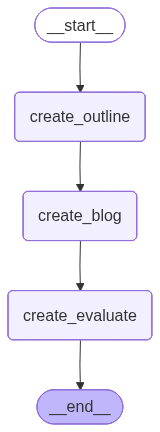

In [44]:
# Create your graph first
graph = StateGraph(BlogState)


# Add nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('create_evaluate', create_evaluate)


# Add edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'create_evaluate')
graph.add_edge('create_evaluate', END)

# compile the workflow
workflow = graph.compile()
workflow

In [45]:
# execute the workflow
initial_state = {'title':"How to be an AI engineer?"}
final_state = workflow.invoke(initial_state)
print(final_state)

{'title': 'How to be an AI engineer?', 'outline': '**Blog Outline – “How to Become an AI Engineer”**\n\n---\n\n### 1. Introduction  \n- **Hook:** A quick anecdote or statistic (e.g., “The demand for AI engineers has grown 74% YoY”)  \n- **What an AI Engineer Does:** Blend of software engineering, data science, and domain expertise.  \n- **Who This Guide Is For:** Students, career‑switchers, and self‑taught tech enthusiasts.\n\n---\n\n### 2. Why Choose AI Engineering?  \n- **Career Outlook & Salary Trends**  \n- **Impactful Applications:** Healthcare, finance, autonomous systems, etc.  \n- **Skill Synergy:** How AI engineering builds on existing software‑dev foundations.\n\n---\n\n### 3. Core Foundations You Must Master  \n\n| Domain | Key Topics | Typical Resources |\n|--------|------------|-------------------|\n| **Mathematics** | Linear algebra, calculus, probability & statistics, optimization | MIT OCW, Khan Academy, “Mathematics for Machine Learning” |\n| **Programming** | Python (

In [ ]:
print(final_state['outline'])

In [ ]:
final_state['blog_content']

'# How to Become an AI Engineer  \n*Your step‑by‑step roadmap from zero to production‑ready AI pro*  \n\n---\n\n## 1. Introduction  \n\n> **“The demand for AI engineers has grown 74\u202f% year‑over‑year, and the median salary now sits north of $130\u202fK in the U.S.”** – *LinkedIn Emerging Jobs Report, 2024*  \n\nIf you’ve ever stared at a chatbot that actually understood you, marveled at a self‑driving car navigating a busy street, or wondered how Netflix seems to know exactly what you’ll binge next, you’ve already seen the work of an AI engineer.  \n\n**What does an AI engineer do?**  \nIn a nutshell, an AI engineer is a **software engineer who specializes in building, scaling, and maintaining intelligent systems**. The role sits at the intersection of three worlds:\n\n| Domain | Typical Tasks |\n|--------|---------------|\n| **Software Engineering** | Write clean, testable code; design APIs; manage deployments |\n| **Data Science / Machine Learning** | Choose models, train, evalua

In [ ]:
final_state['evaluate']

'**Evaluation of the “How to Become an AI Engineer” Blog Post**\n\n---\n\n## 1. Overall Impression  \nThe article is a **comprehensive, well‑structured roadmap** that walks a complete beginner from zero to a production‑ready AI engineer. It balances high‑level career context with concrete technical steps, resources, and actionable deliverables. The mix of tables, code snippets, and “quick‑demo” sections makes it **scannable** and **practically useful**.\n\n**Score (out of 10):** **8.5**\n\n---\n\n## 2. Strengths  \n\n| Area | What Works Well | Why It Adds Value |\n|------|----------------|-------------------|\n| **Clear Audience Definition** | Opens with “students, career‑switchers, self‑taught enthusiasts”. | Sets expectations and attracts the right readers. |\n| **Data‑Driven Motivation** | Uses recent LinkedIn/Glassdoor stats, salary tables, job‑opening growth. | Gives a compelling business case for the career switch. |\n| **Logical Learning Path** | Breaks the journey into phases (